# 07 - Verify YOLO Labels
Kiểm tra chất lượng labels sau khi annotate bằng LabelImg

In [25]:
import os
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from pathlib import Path

In [26]:
# Config
LABELING_DIR = "../data/yolo_labeling"
CLASS_NAMES = ["rice_leaf"]  # Tên class dùng khi label

In [27]:
# ── 1. Kiểm tra tổng quan ──────────────────────────────────────────────
all_images = [f for f in os.listdir(LABELING_DIR) if f.endswith(('.jpg', '.jpeg', '.png'))]
all_labels = [f for f in os.listdir(LABELING_DIR) if f.endswith('.txt') and f != 'file_list.txt']

print(f"Total images : {len(all_images)}")
print(f"Total labels : {len(all_labels)}")
print(f"Not yet labeled: {len(all_images) - len(all_labels)}")

# Tìm ảnh chưa có label
labeled_stems = {Path(f).stem for f in all_labels}
unlabeled = [f for f in all_images if Path(f).stem not in labeled_stems]

if unlabeled:
    print(f"\n  Unlabeled images ({len(unlabeled)}):")
    for f in unlabeled[:10]:
        print(f"  - {f}")
    if len(unlabeled) > 10:
        print(f"  ... and {len(unlabeled)-10} more")
else:
    print("\n All images have been labeled!")

Total images : 1106
Total labels : 1129
Not yet labeled: -23

 All images have been labeled!


In [28]:
# ── 2. Kiểm tra format YOLO ────────────────────────────────────────────
errors = []
empty_labels = []
valid_count = 0
total_boxes = 0

for label_file in all_labels:
    if label_file == "classes.txt":
        continue
    label_path = os.path.join(LABELING_DIR, label_file)
    
    with open(label_path, 'r') as f:
        lines = f.read().strip().splitlines()
    
    if not lines:
        empty_labels.append(label_file)
        continue
    
    file_ok = True
    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            errors.append(f"{label_file}: wrong format '{line}'")
            file_ok = False
            continue
        
        try:
            cls_id = int(parts[0])
            x, y, w, h = map(float, parts[1:])
            
            # Kiểm tra giá trị hợp lệ
            if not (0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1):
                errors.append(f"{label_file}: out of range [{x:.3f},{y:.3f},{w:.3f},{h:.3f}]")
                file_ok = False
            else:
                total_boxes += 1
        except ValueError:
            errors.append(f"{label_file}: cannot parse '{line}'")
            file_ok = False
    
    if file_ok:
        valid_count += 1

print(f"Valid label files : {valid_count}")
print(f"Empty label files : {len(empty_labels)}")
print("\nEmpty label files:")
for f in empty_labels:
    print(" ", f)
print(f"Format errors     : {len(errors)}")
print(f"Total bounding boxes: {total_boxes}")
print(f"Avg boxes/image   : {total_boxes/max(valid_count,1):.2f}")

if errors:
    print("\n❌ Errors found:")
    for e in errors[:5]:
        print(f"  {e}")
else:
    print("\n✅ All label formats OK!")

Valid label files : 1128
Empty label files : 0

Empty label files:
Format errors     : 0
Total bounding boxes: 1209
Avg boxes/image   : 1.07

✅ All label formats OK!


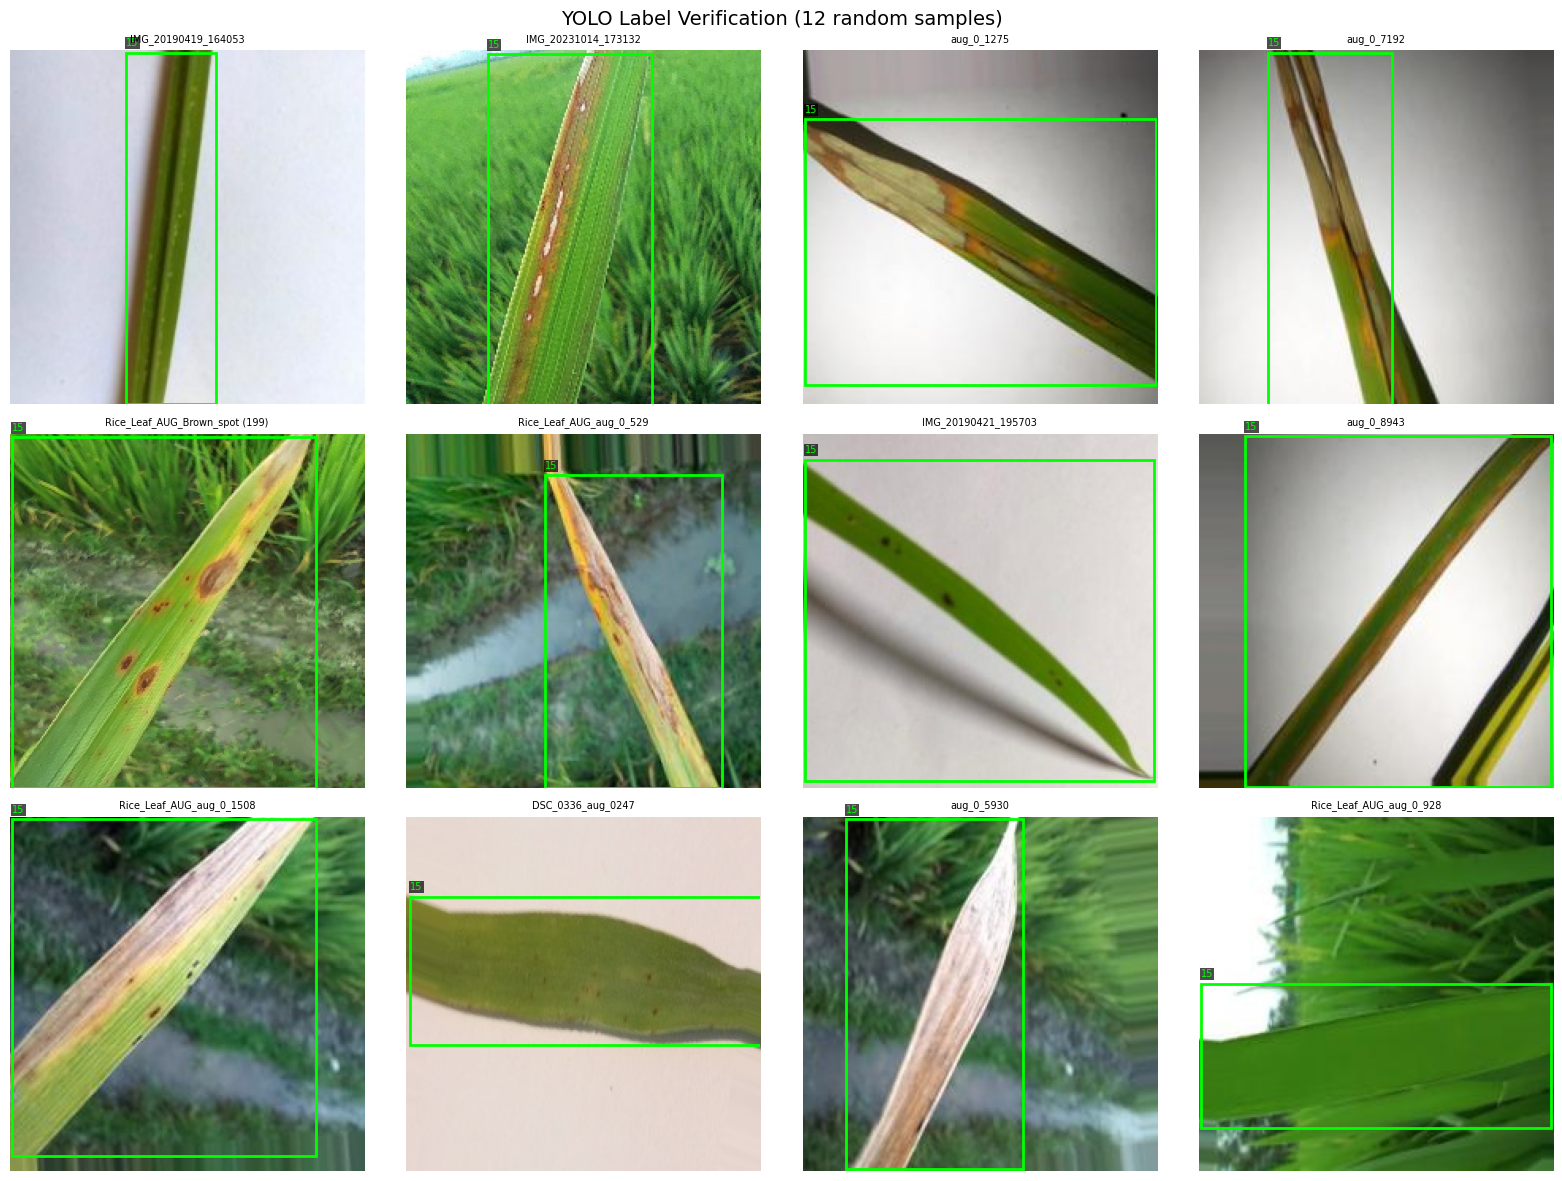

In [29]:
# ── 3. Visualize 12 ảnh ngẫu nhiên với bounding box ───────────────────
import random
random.seed(0)

# Lấy những ảnh đã có label hợp lệ
valid_pairs = []
for img_file in all_images:
    stem = Path(img_file).stem
    label_file = stem + '.txt'
    label_path = os.path.join(LABELING_DIR, label_file)
    if os.path.exists(label_path):
        valid_pairs.append((img_file, label_file))

sample_pairs = random.sample(valid_pairs, min(12, len(valid_pairs)))

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for ax, (img_file, label_file) in zip(axes, sample_pairs):
    img_path = os.path.join(LABELING_DIR, img_file)
    label_path = os.path.join(LABELING_DIR, label_file)
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    ax.imshow(img)
    
    with open(label_path, 'r') as f:
        for line in f.read().strip().splitlines():
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls_id = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:])
            
            # YOLO → pixel
            x1 = (cx - bw/2) * w
            y1 = (cy - bh/2) * h
            box_w = bw * w
            box_h = bh * h
            
            rect = patches.Rectangle(
                (x1, y1), box_w, box_h,
                linewidth=2, edgecolor='lime', facecolor='none'
            )
            ax.add_patch(rect)
            cls_name = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else str(cls_id)
            ax.text(x1, y1-4, cls_name, color='lime', fontsize=7,
                    bbox=dict(boxstyle='square,pad=0.1', fc='black', ec='none', alpha=0.7))
    
    ax.set_title(Path(img_file).stem[:30], fontsize=7)
    ax.axis('off')

plt.suptitle('YOLO Label Verification (12 random samples)', fontsize=14)
plt.tight_layout()
plt.show()

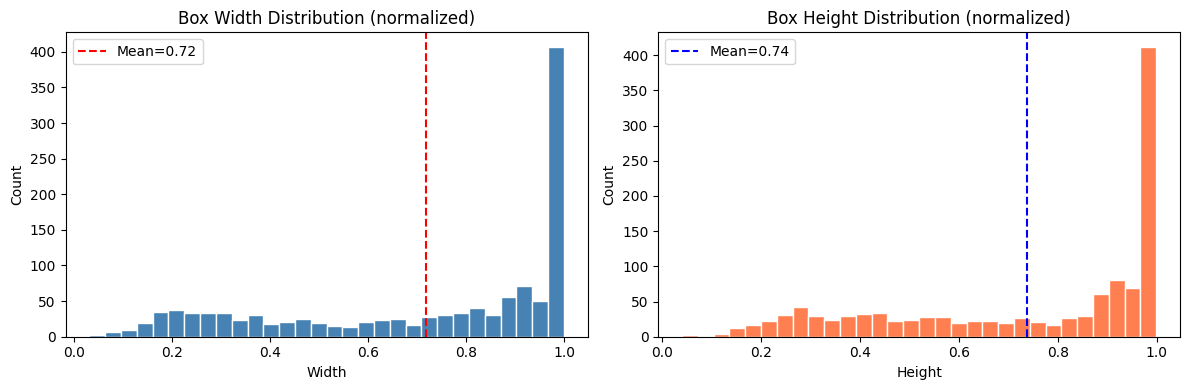

Box width  → mean=0.718, std=0.298
Box height → mean=0.737, std=0.278


In [23]:
# ── 4. Phân bố box size ───────────────────────────────────────────────
box_widths = []
box_heights = []

for label_file in all_labels:
    label_path = os.path.join(LABELING_DIR, label_file)
    with open(label_path, 'r') as f:
        for line in f.read().strip().splitlines():
            parts = line.strip().split()
            if len(parts) == 5:
                box_widths.append(float(parts[3]))
                box_heights.append(float(parts[4]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(box_widths, bins=30, color='steelblue', edgecolor='white')
ax1.set_title('Box Width Distribution (normalized)')
ax1.set_xlabel('Width')
ax1.set_ylabel('Count')
ax1.axvline(np.mean(box_widths), color='red', linestyle='--', label=f'Mean={np.mean(box_widths):.2f}')
ax1.legend()

ax2.hist(box_heights, bins=30, color='coral', edgecolor='white')
ax2.set_title('Box Height Distribution (normalized)')
ax2.set_xlabel('Height')
ax2.set_ylabel('Count')
ax2.axvline(np.mean(box_heights), color='blue', linestyle='--', label=f'Mean={np.mean(box_heights):.2f}')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Box width  → mean={np.mean(box_widths):.3f}, std={np.std(box_widths):.3f}")
print(f"Box height → mean={np.mean(box_heights):.3f}, std={np.std(box_heights):.3f}")

In [24]:
# ── 5. Summary ────────────────────────────────────────────────────────
print("="*60)
print("VERIFICATION SUMMARY")
print("="*60)
print(f"Total images         : {len(all_images)}")
print(f"Labeled              : {len(all_labels)}")
print(f"Unlabeled            : {len(unlabeled)}")
print(f"Valid labels         : {valid_count}")
print(f"Empty labels         : {len(empty_labels)}")
print(f"Format errors        : {len(errors)}")
print(f"Total boxes          : {total_boxes}")

if len(errors) == 0 and len(unlabeled) == 0:
    print("\n READY for 08_prepare_yolo_dataset.ipynb")
else:
    print("\n  Fix issues above before proceeding")

VERIFICATION SUMMARY
Total images         : 1106
Labeled              : 1129
Unlabeled            : 0
Valid labels         : 1128
Empty labels         : 0
Format errors        : 0
Total boxes          : 1209

 READY for 08_prepare_yolo_dataset.ipynb
